In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import sys
sys.path.append('../src')

from impact_modeling import EventImpactModel


Loaded 66 total records
  - 12 events
  - 2 impact links
  - 49 observations

Available columns in impact_links: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes', 'event_name', 'parent_id', 'event_id']
No impact matrix created - check if impact links exist in your data

=== Validating Telebirr Impact ===

Telebirr Launch Validation:
        date  actual  predicted  error
0 2021-12-31    4.70        4.7   0.00
1 2024-11-29    9.45        4.7  -4.75


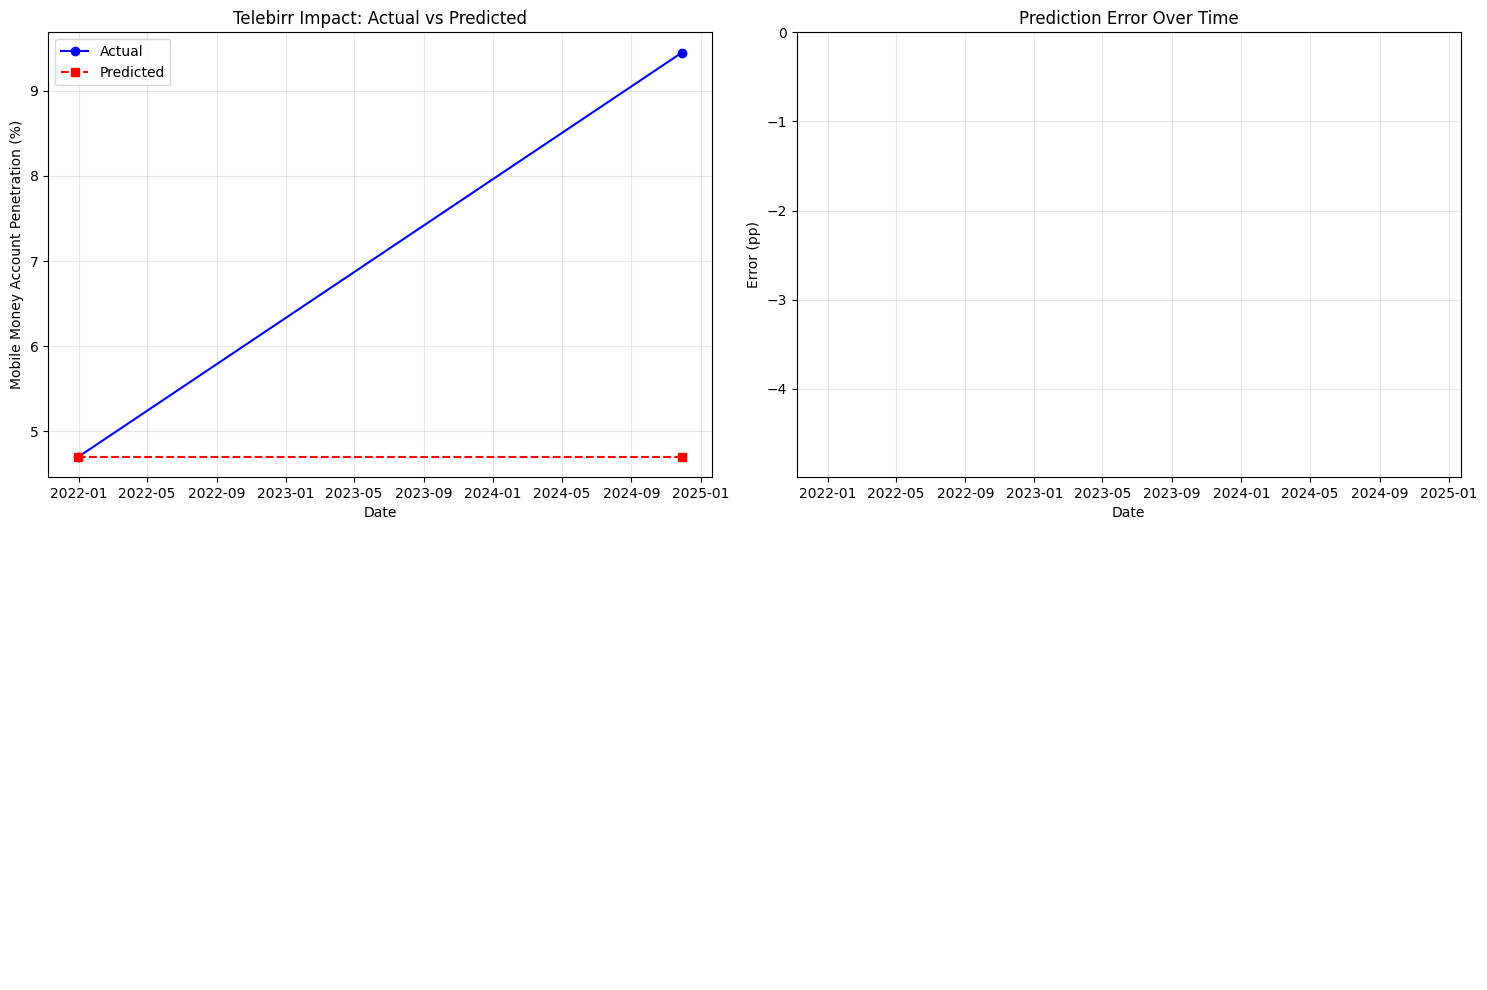


=== Creating Event Timeline ===


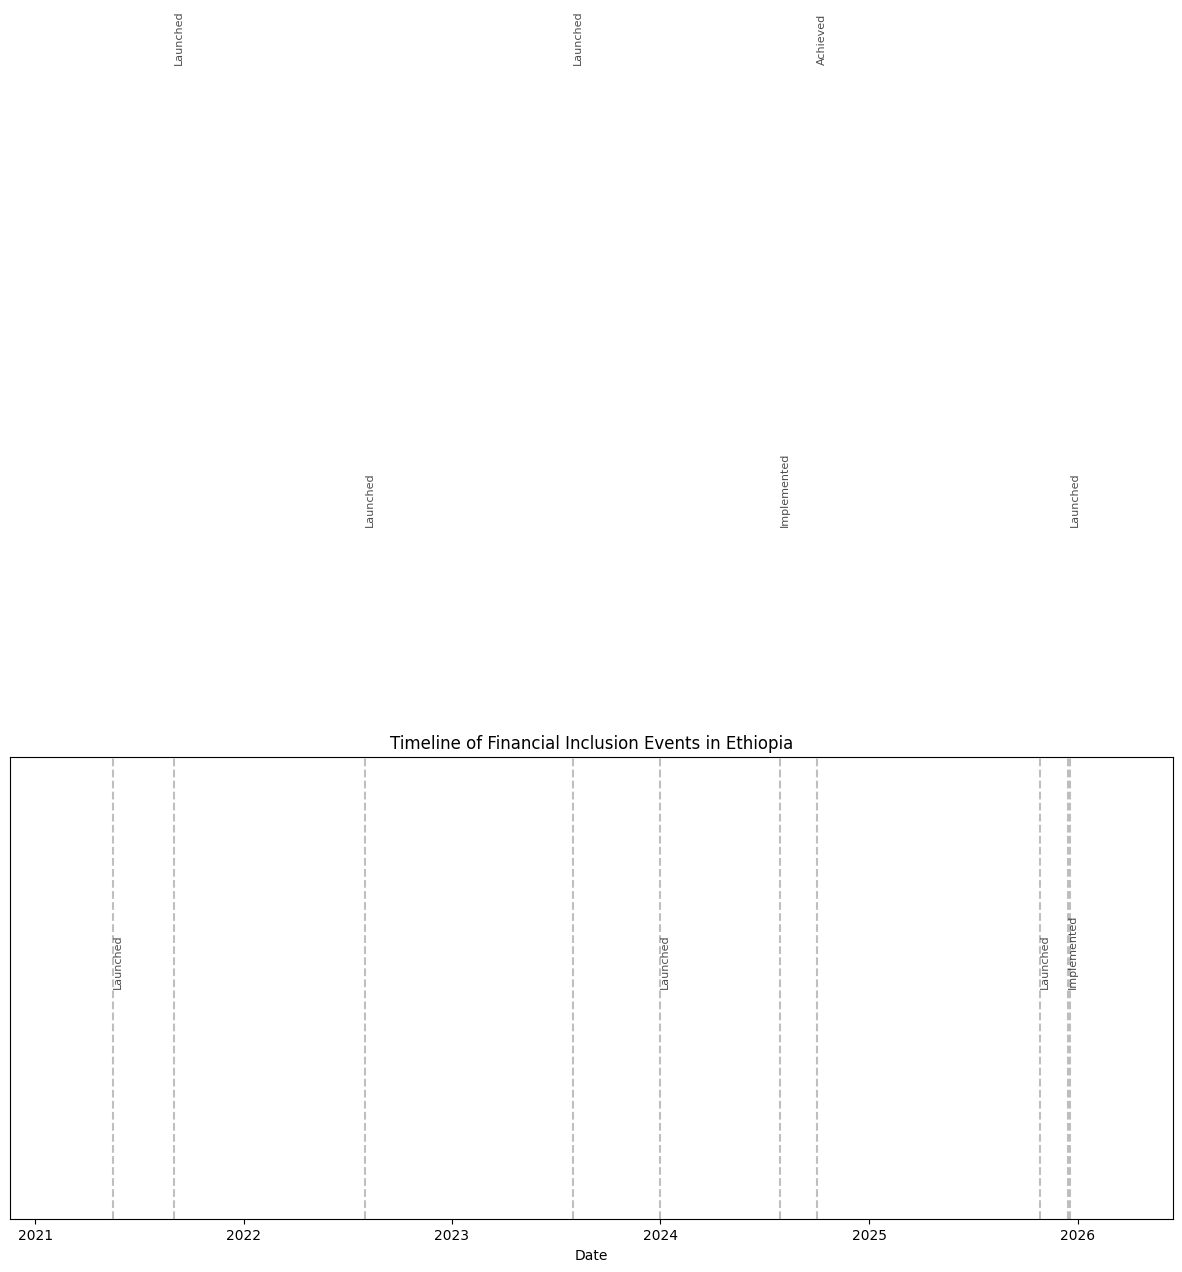


Methodology Documented in ../models/model_methodology.json


In [6]:
# Initialize model
model = EventImpactModel(r'C:\Users\admin\Ethiopia-fi-forecast\data\processed\enriched_data_fixed.csv')

# 1. Create Event-Indicator Association Matrix
matrix = model.create_event_indicator_matrix()

if len(matrix) > 0:
    print("Event-Indicator Association Matrix:")
    print(matrix.head())
    
    # Save matrix
    matrix.to_csv('../models/event_indicator_matrix.csv', index=False)
    
    # 2. Visualize as Heatmap (only if we have data)
    if len(matrix) > 1:
        plt.figure(figsize=(12, 8))
        # Use event_name as index, show only numeric columns
        numeric_cols = matrix.select_dtypes(include=[np.number]).columns
        heatmap_data = matrix.set_index('event_name')[numeric_cols]
        
        if not heatmap_data.empty:
            sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', 
                        center=0, linewidths=0.5)
            plt.title('Event Impact Matrix (Positive/Negative Effects on Indicators)')
            plt.tight_layout()
            plt.savefig('../reports/figures/event_impact_matrix.png', dpi=300, bbox_inches='tight')
            plt.show()
        else:
            print("No numeric data to plot in heatmap")
    else:
        print("Not enough events to create heatmap")
else:
    print("No impact matrix created - check if impact links exist in your data")
    
# 3. Validate Against Historical Data
print("\n=== Validating Telebirr Impact ===")
telebirr_validation = model.validate_against_historical('ACC_MM_ACCOUNT')

if not telebirr_validation.empty:
    print("\nTelebirr Launch Validation:")
    print(telebirr_validation.head())
    
    # Plot validation results
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Actual vs Predicted
    axes[0, 0].plot(telebirr_validation['date'], telebirr_validation['actual'], 
                    'b-', label='Actual', marker='o')
    axes[0, 0].plot(telebirr_validation['date'], telebirr_validation['predicted'], 
                    'r--', label='Predicted', marker='s')
    axes[0, 0].set_title('Telebirr Impact: Actual vs Predicted')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Mobile Money Account Penetration (%)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Error analysis
    axes[0, 1].bar(telebirr_validation['date'], telebirr_validation['error'])
    axes[0, 1].set_title('Prediction Error Over Time')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Error (pp)')
    axes[0, 1].axhline(y=0, color='r', linestyle='-', alpha=0.3)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Hide empty subplots
    axes[1, 0].axis('off')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/telebirr_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. Analyze Individual Event Impacts
    if len(matrix) > 0:
        key_events = ['Telebirr Launch (May 2021)', 'M-Pesa Entry (Aug 2023)', 
                      'NFIS-II Policy (2021)', 'Safaricom License (Aug 2022)']
        
        for event_name in key_events:
            event_data = matrix[matrix['event_name'] == event_name]
            if len(event_data) > 0:
                print(f"\n{event_name} Impact Profile:")
                available_cols = [col for col in ['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'USG_DIGITAL_PAYMENT']
                                  if col in event_data.columns]
                if available_cols:
                    impacts = event_data.iloc[0][available_cols]
                    print(impacts)
else:
    print("No validation data available for Telebirr")

# 5. Create Impact Timeline Visualization
print("\n=== Creating Event Timeline ===")
events = model.events.copy()

if len(events) > 0:
    # Convert dates, drop invalid ones
    events['date'] = pd.to_datetime(events['observation_date'], errors='coerce')
    events = events.dropna(subset=['date']).sort_values('date')
    
    if len(events) > 0:
        fig, ax = plt.subplots(figsize=(15, 6))
        
        for idx, event in events.iterrows():
            y_pos = idx % 3 + 0.5  # Stagger events vertically
            ax.axvline(x=event['date'], color='gray', alpha=0.5, linestyle='--')
            
            event_name = event.get('value_text', event.get('event_name', f"Event {idx}"))
            ax.text(event['date'], y_pos, str(event_name)[:30], 
                    rotation=90, fontsize=8, alpha=0.7, va='bottom')
        
        # Set x-axis limits with buffer
        min_date = events['date'].min() - pd.Timedelta(days=180)
        max_date = events['date'].max() + pd.Timedelta(days=180)
        ax.set_xlim(min_date, max_date)
        
        ax.set_title('Timeline of Financial Inclusion Events in Ethiopia')
        ax.set_xlabel('Date')
        ax.set_yticks([])
        plt.tight_layout()
        plt.savefig('../reports/figures/event_timeline.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("No valid dates found for timeline")
else:
    print("No events found for timeline")

# 6. Document Methodology
methodology = {
    "approach": "Event-Impact Association Matrix with Time-Dependent Functions",
    "key_assumptions": [
        "Event impacts follow predetermined functional forms (policy, launch, infrastructure)",
        "Impacts have linear ramp-up periods",
        "Effects combine additively",
        "Historical validation informs magnitude adjustments"
    ],
    "uncertainties": [
        "Limited pre/post data for many events",
        "Interaction effects between events not modeled",
        "External economic factors not included",
        "Ethiopia-specific adoption rates may differ from global benchmarks"
    ]
}

# Add validation results if available
if not telebirr_validation.empty and 'error' in telebirr_validation.columns:
    errors = telebirr_validation['error'].dropna()
    if len(errors) > 0:
        methodology["validation_results"] = {
            "telebirr_rmse": np.sqrt(np.mean((errors ** 2))),
            "telebirr_mae": np.mean(np.abs(errors)),
            "coverage": f"{len(matrix)} events impacting {len(matrix.columns)-4 if len(matrix)>0 else 0} indicators"
        }

# Save methodology documentation
import json
with open('../models/model_methodology.json', 'w') as f:
    json.dump(methodology, f, indent=4)

print("\nMethodology Documented in ../models/model_methodology.json")
